# Partie 1 : Classification Images

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [9]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML2/ProjetClip'
sys.path.append(my_local_drive)
%cd $my_local_drive

/content/gdrive/My Drive/Colab Notebooks/ML2/ProjetClip


In [10]:
import os
import pandas as pd
import re
import numpy as np
import random
import zipfile
import requests
import io
import math
from pathlib import Path
import cv2

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.utils import register_keras_serializable, to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model
from tensorflow.keras.metrics import Mean
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Pour utiliser au mieux le GPU
AUTOTUNE = tf.data.AUTOTUNE

# Récupération du jeu de données

In [4]:
url = "https://www.lirmm.fr/~poncelet/Ressources/flickr_subset2.zip"
target_dir = "flickr_subset2"

# Vérifie si le dossier existe déjà
if os.path.exists(target_dir) and os.path.isdir(target_dir):
    print("Données déjà disponibles dans :", target_dir)
else:
    print("Téléchargement de flickr_subset2.zip...")
    response = requests.get(url)
    if response.status_code == 200:
        print("Téléchargement réussi. Extraction...")
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
            # Extraire sans ajouter de sous-dossier supplémentaire
            for member in zip_ref.namelist():
                # Corrige les chemins pour ignorer un éventuel prefixe flickr_subset2/
                member_path = member
                if member.startswith("flickr_subset2/"):
                    member_path = member[len("flickr_subset2/"):]
                target_path = os.path.join(target_dir, member_path)

                # Si c'est un répertoire, on le crée
                if member.endswith("/"):
                    os.makedirs(target_path, exist_ok=True)
                else:
                    os.makedirs(os.path.dirname(target_path), exist_ok=True)
                    with zip_ref.open(member) as source, open(target_path, "wb") as target:
                        target.write(source.read())
        print(f"Données extraites dans : {target_dir}")
    else:
        print("Échec du téléchargement. Code HTTP :", response.status_code)

Données déjà disponibles dans : flickr_subset2


In [11]:
# Répertoire cible pour sauvegarder vos modèles
model_dir = "./models_forclip"
os.makedirs(model_dir, exist_ok=True)

# Répertoire des données
dataset_dir = "./flickr_subset2"

# Répertoire des images
image_dir = os.path.join(dataset_dir, "images")
# Répertoire des captions
captions_dir = os.path.join(dataset_dir, "captions")

# Visualisation

In [6]:
def preview_images_from_dir(image_dir, image_size=(224, 224), n=12,
                            subset="training", seed=123):
    """
    Affiche n images avec leurs labels à partir d'un dossier
    (flow_from_directory).
    N'utilise PAS train_gen pour ne pas en avancer l'index.
    """
    # Générateur léger juste pour l'aperçu
    # Ici il y a une bonne indication si vous regardez bien pour la classif :)
    preview_datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)

    preview_gen = preview_datagen.flow_from_directory(
        image_dir,
        target_size=image_size,
        batch_size=n,
        class_mode="categorical",
        subset=subset,
        shuffle=True,
        seed=seed
    )

    imgs, y = next(preview_gen)    # imgs: (n, H, W, 3), y: one-hot
    class_names = list(preview_gen.class_indices.keys())
    labels = np.argmax(y, axis=1)

    rows = 3
    cols = int(np.ceil(n / rows))
    plt.figure(figsize=(4*cols, 4*rows))
    for i in range(min(n, imgs.shape[0])):
        plt.subplot(rows, cols, i+1)
        plt.imshow(imgs[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


In [9]:
# Affichage des images
preview_images_from_dir(image_dir, image_size=image_size, n=12, subset="training", seed=42)

Output hidden; open in https://colab.research.google.com to view.

**Remarques :**
- Les images sont en couleurs et ont une taille de 224x224. Cela veut dire qu'elles prennent beaucoup de place et qu'il n'est pas possible de les charger directement en mémoire pour l'apprentissage ou la validation. Il est donc indispensable de les envoyer à la volée, i.e. par batches. **Astuce :** Chercher dans les guides comment faire pour envoyer les images à la volée à partir d'un répertoire.
- L'entraînement du modèle peut être long aussi il est préférable de le sauvegarder au fur et à mesure. Pour cela dans la cellule ci-dessous vous trouverez une autre fonction callback : `ModelCheckpoint`. Elle sauvegarde à chaque epoch dans model_path (qui est initialisé en début de cellule) le modèle Keras avec les meilleurs poids. Vous verrez que la mesure suivie est la val_loss. Si elle s'améliore le modèle est sauvegardé. L'avantage est qu'en cas de problème vous aurez toujours une version sauvegardé.
- Pour votre loss, vous pourrez utiliser `loss="categorical_crossentropy"`. Comme optimizer, utiliser `optimizer="adam"`.    

**Conseil :** l'apprentissage d'un modèle peut être très long. Il est important avant de mettre un trop grand nombre d'epochs de vérifier que la sauvegarde de votre modèle est bien réalisée et que vous pouvez le recharger. Il n'y a rien de pire que d'attendre des heures et de se rendre compte qu'on a mal sauvegardé le modèle et qu'il faut tout recommencer !!! Normalement ici les fonctions (correspondant aux couches) utilisées sont "*built-in*", i.e. Keras les connait et ne posera pas de problèmes, il sait les sérialiser. Par contre dès que vous allez devoir définir des couches plus personnalisées il va falloir penser à mettre des *décorateurs* qui préciseront comment sérialiser le modèle pour le sauvegarder. Cela sera très utile pour la suite. Vous pouvez voir dans la partie classe utile pour la suite des exemples de décorateur (e.g `@tf.keras.utils.register_keras_serializable()`).  

# Début

### Fonctions d'évaluation (visuelle)

In [6]:
# Cellule générée par ChatGPT

def plot_history_simple(history):
    """
    Trace côte à côte les courbes Loss et Accuracy (train/val si dispo)
    à partir d'un objet Keras History.
    """
    hist = history.history

    # compatibilité anciennes versions ("acc"/"val_acc")
    acc_key = "accuracy" if "accuracy" in hist else "acc"
    val_acc_key = "val_accuracy" if "val_accuracy" in hist else "val_acc"

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss" in hist:
        axes[0].plot(hist["loss"], label="train")
    if "val_loss" in hist:
        axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # --- Accuracy ---
    if acc_key in hist:
        axes[1].plot(hist[acc_key], label="train")
        if val_acc_key in hist:
            axes[1].plot(hist[val_acc_key], label="val")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
    else:
        axes[1].set_visible(False)  # si pas d'accuracy, on masque le 2e plot

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_simple(y_true, y_pred, labels=(0,1),
                                 normalize=None, title="Confusion matrix"):
    """
    Affiche une matrice de confusion.
    Args:
        y_true, y_pred : vecteurs de labels
        labels         : ordre des classes à afficher
        normalize      : None, 'true', 'pred', ou 'all' (comme scikit-learn)
        title          : titre de la figure
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=normalize)
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel="Predicted label",
        ylabel="True label",
      title=title if normalize is None else f"{title} (normalized: {normalize})"
    )

    # annotations
    thresh = cm.max() / 2.0 if cm.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            ax.text(j, i, txt,
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

def plot_history_cv_mean_std(all_histories, alpha=0.2):
    """
    all_histories : list[pd.DataFrame]
        Chaque DF doit contenir : ['accuracy','loss','val_accuracy','val_loss','epoch','fold'].
        (c'est exactement ton format actuel)

    Trace loss et accuracy (train/val) avec moyenne ± écart-type par epoch.
    Si certains folds s'arrêtent plus tôt (early stopping), la moyenne/STD
    sur les dernières époques est calculée sur les folds encore présents.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1) Concat & agrégation
    df = pd.concat(all_histories, ignore_index=True)
    cols = [c for c in ["loss", "val_loss", "accuracy", "val_accuracy"] if c in df.columns]
    stats = df.groupby("epoch")[cols].agg(["mean", "std"])
    stats.columns = [f"{m}_{s}" for m, s in stats.columns]  # ex: ('loss','mean')->'loss_mean'
    stats = stats.reset_index()
    epochs = stats["epoch"].values

    # 2) Plot côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss ---
    if "loss_mean" in stats:
        axes[0].plot(epochs, stats["loss_mean"], label="train")
        if "loss_std" in stats:
            axes[0].fill_between(epochs, stats["loss_mean"]-stats["loss_std"],
                                          stats["loss_mean"]+stats["loss_std"], alpha=alpha)
    if "val_loss_mean" in stats:
        axes[0].plot(epochs, stats["val_loss_mean"], label="val")
        if "val_loss_std" in stats:
            axes[0].fill_between(epochs, stats["val_loss_mean"]-stats["val_loss_std"],
                                          stats["val_loss_mean"]+stats["val_loss_std"], alpha=alpha)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    # --- Accuracy ---
    if "accuracy_mean" in stats:
        axes[1].plot(epochs, stats["accuracy_mean"], label="train")
        if "accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["accuracy_mean"]-stats["accuracy_std"],
                                          stats["accuracy_mean"]+stats["accuracy_std"], alpha=alpha)
    if "val_accuracy_mean" in stats:
        axes[1].plot(epochs, stats["val_accuracy_mean"], label="val")
        if "val_accuracy_std" in stats:
            axes[1].fill_between(epochs, stats["val_accuracy_mean"]-stats["val_accuracy_std"],
                                          stats["val_accuracy_mean"]+stats["val_accuracy_std"], alpha=alpha)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

def plot_decision_boundary(pipe, X, y=None, title=None, h=0.02, padding=0.5, threshold=0.5, ax=None):
    """
    Affiche la frontière de décision d'un modèle 2D (ex: make_moons).
    pipe : Pipeline déjà fit (ex: StandardScaler + KerasClassifier)
    X, y : données à superposer (y optionnel pour juste la frontière)
    h : pas de la grille, padding : marge autour des données
    threshold : seuil de classification si proba disponible
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,5))

    # -- Grille 2D
    x_min, x_max = X[:,0].min()-padding, X[:,0].max()+padding
    y_min, y_max = X[:,1].min()-padding, X[:,1].max()+padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # -- Prédiction robuste (proba > decision_function > predict)
    Z = None
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(grid)
        # binaire : colonnes [p(classe0), p(classe1)] ou vecteur
        Z = proba[:,1] if proba.ndim == 2 and proba.shape[1] > 1 else proba.ravel()
    elif hasattr(pipe, "decision_function"):
        s = pipe.decision_function(grid).ravel()
        # Normalisation sigmoïde légère sans SciPy
        Z = 1 / (1 + np.exp(-s))
    else:
        # chute de secours : classes {0,1}
        Z = pipe.predict(grid).ravel().astype(float)

    Z_grid = Z.reshape(xx.shape)

    # -- Fond coloré + ligne de frontière
    # si Z est proba, on trace la courbe de niveau au seuil; sinon on sépare 0/1
    if np.unique(Z).size > 2 or (Z.min() >= 0 and Z.max() <= 1):
        ax.contourf(xx, yy, Z_grid, levels=50, alpha=0.25)
        ax.contour(xx, yy, (Z_grid >= threshold).astype(int), levels=[0.5], colors="k", linewidths=1)
    else:
        ax.contourf(xx, yy, Z_grid, levels=[-0.5,0.5,1.5], alpha=0.25)
        ax.contour(xx, yy, Z_grid, levels=[0.5], colors="k", linewidths=1)

    # -- Nuage de points (si y fourni)
    if y is not None:
        ax.scatter(X[:,0], X[:,1], c=y, s=25, edgecolor="k", linewidth=0.5)

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    if title:
        ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    return ax

def plot_examples(X,y,nb_columns=25):
  plt.figure(figsize=(15,15))
  for i in range(nb_columns):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # cv2 lit met les images en BGR et matplotlib lit du RGB
    X[i] = cv2.cvtColor(X[i], cv2.COLOR_BGR2RGB)
    plt.imshow(X[i]/255.,cmap=plt.cm.binary)
    plt.xlabel('classe ' + str(y[i]))

### Paramètres utiles

In [5]:
# Variables utiles
# Attention respecter bien l'ordre alphabétique des classes pour le générateur
class_names = ['ball', 'bike', 'dog', 'water']
# Pour les images
image_size=(224, 224)
image_shape = image_size + (3,)

# Pour les images et les textes dans le modèle CLIP
embed_dim = 128

### Création de dossiers Train et Test

In [ ]:
def create_training_data(path_all_data=image_dir):
  path_write_train=os.path.join(path_all_data, "train")
  path_write_test=os.path.join(path_all_data, "test")

  if os.path.exists(path_all_data) and os.path.isdir(path_write_train) and os.path.isdir(path_write_test):
    print("Données déjà disponibles")
    return True

  img_idx=list(range(1,151))
  img_idx += img_idx
  img_idx += img_idx
  img_idx = [str(x).zfill(3) for x in img_idx]
  labels = ['ball']*150
  labels += ['bike']*150
  labels += ['dog']*150
  labels += ['water']*150

  X_train, X_test, y_train, y_test = train_test_split(img_idx, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels)

  for i in range(len(X_train)):
    img_path = y_train[i] + "/" + y_train[i] + "_" + X_train[i] + ".jpg"
    try:
      img = cv2.imread(os.path.join(path_all_data,img_path), cv2.IMREAD_UNCHANGED)
      cv2.imwrite(os.path.join(path_write_train,img_path), img)
    except Exception as e:
      return False

  for i in range(len(X_test)):
    img_path = y_test[i] + "/" + y_test[i] + "_" + X_test[i] + ".jpg"
    try:
      img = cv2.imread(os.path.join(path_all_data,img_path), cv2.IMREAD_UNCHANGED)
      cv2.imwrite(os.path.join(path_write_test,img_path), img)
    except Exception as e:
      return False

  if os.path.exists(path_all_data) and os.path.isdir(path_write_train) and os.path.isdir(path_write_test):
    print("Train_test_split réussi")
    return True
  else:
    return False

In [25]:
print(create_training_data())

True


### Récupération des données par batch (optimisation de mémoire)
### + nettoyage

In [24]:

def create_testing_data(path_data, list_classes):
  testing_data=[]
  for classes in list_classes:
      path=os.path.join(path_data, classes)
      class_num=list_classes.index(classes)
      for img in os.listdir(path):
        try:
          img_array = cv2.imread(os.path.join(path,img), cv2.IMREAD_UNCHANGED)
          new_array = cv2.resize(img_array, image_size)
          testing_data.append([new_array, class_num])
        except Exception as e:
          pass
  return testing_data


def create_X_y_test (path_data, list_classes):
      # récupération des données
      testing_data=create_testing_data(path_data, list_classes)
      # tri des données
      random.shuffle(testing_data)
      # création de X et y
      X_test=[]
      y_test=[]
      for features, label in testing_data:
        X_test.append(features)
        y_test.append(label)
      X_test=np.array(X_test).reshape(-1,image_size[0], image_size[1], 3)
      X_test = X_test.astype('float32')
      X_test /= 255.0
      y_test= to_categorical(np.array(y_test))
      print("Create X y test OK")
      return X_test,y_test


In [22]:
"""
Étapes :
- 1) récupérer les données par batch
- 2) resize
- 4) Conversion des entiers en floats pour permettre la normalisation : X=X.astype('float')
- 5) normaliser : X=X/255.0
- 3) one-hot du y
"""

def load_clean_data():
  # flow pour X_train et y_train
  train_generator = ImageDataGenerator(validation_split=0.2, rescale=1./255)
  train_flow = train_generator.flow_from_directory(
      directory=os.path.join(image_dir, "train"),
      target_size=image_size,
      classes=class_names,
      class_mode="categorical", # Encodage one-hot des étiquettes
      shuffle=True,
      seed=42,
      subset='training'
  )

  val_flow = train_generator.flow_from_directory(
      directory=os.path.join(image_dir, "train"),
      target_size=image_size,
      classes=class_names,
      class_mode="categorical", # Encodage one-hot des étiquettes
      shuffle=True,
      seed=42,
      subset='validation'
  )
  print("Create train flow OK")

  # Traitement en bloc pour X_test et y_test
  X_test, y_test = create_X_y_test(os.path.join(image_dir, "test"), class_names)

  return train_flow, val_flow, X_test, y_test


### Création du modèle

In [50]:
def define_cnn_model(input_dim=image_shape, learning_rate=1e-3, loss="categorical_crossentropy", metrics=["accuracy"]):

    input = Input(shape=input_dim, name="Input Layer")

    # À AJUSTER
    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_1")(input)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_1")(conv)

    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_2")(maxPool)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_2")(conv)

    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_3")(maxPool)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_3")(conv)

    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_4")(maxPool)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_4")(conv)

    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_5")(maxPool)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_5")(conv)

    conv = Conv2D(filters=32, kernel_size=(3, 3), activation='relu', name="Conv2D_6")(maxPool)
    maxPool = MaxPooling2D(pool_size=(2, 2), name="MaxPooling2D_6")(conv)

    flatten = Flatten(name="Flatten")(maxPool)

    dense = Dense(100, activation='relu', name="Dense")(flatten)


    output = Dense(4, activation='softmax', name="Output")(dense)

    model = Model(inputs=input, outputs=output, name="Classif_Images_for_Clip")

    model.compile(optimizer=Adam(learning_rate), loss=loss, metrics=metrics)

    model.summary()

    return model

### Entraînement du modèle

In [35]:
def train_cnn_model(model, train_flow, val_flow, X_test, y_test, model_save_path, epochs, patience=3):
  callbacks = [
    EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(model_save_path, "best_image_classif.keras"), monitor='val_loss', save_best_only=True, verbose=1)
  ]

  model_history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
  )

  # Évaluation
  loss, accuracy = model.evaluate(X_test, y_test)
  print(f"TEST Loss: {loss}, TEST Accuracy: {accuracy}")

  plot_history_simple(model_history)

  return model

### Main

In [14]:
epochs = 10

learning_rate=1e-3
loss="categorical_crossentropy"
metrics=["accuracy"]

>>> Starting load_clean_data

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.
Create train flow OK
Create X y test OK
>>> Defining model


Model: "Classif_Images_for_Clip"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_1 (MaxPooling2D)   │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_2 (MaxPooling2D)   │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_3 (MaxPooling2D)   │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_4 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_4 (MaxPooling2D)   │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_5 (Conv2D)               │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_5 (MaxPooling2D)   │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_6 (Conv2D)               │ (None, 3, 3, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_6 (MaxPooling2D)   │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 100)            │         3,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,840 (198.59 KB)

 Trainable params: 50,840 (198.59 KB)

 Non-trainable params: 0 (0.00 B)

>>> Training model
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2518 - loss: 1.3874
Epoch 1: val_loss improved from inf to 1.38660, saving model to ./models_forclip/best_image_classif.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.2504 - loss: 1.3876 - val_accuracy: 0.2500 - val_loss: 1.3866
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2592 - loss: 1.3840
Epoch 2: val_loss improved from 1.38660 to 1.38460, saving model to ./models_forclip/best_image_classif.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2599 - loss: 1.3839 - val_accuracy: 0.2500 - val_loss: 1.3846
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2644 - loss: 1.3744
Epoch 3: val_loss did not improve from 1.38460
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.2643 - loss: 1.3747 - val_accuracy: 0.2604 - val_loss: 1.3861
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3537 - loss: 1.3722
Epoch 4: val_loss did not improve from 1.

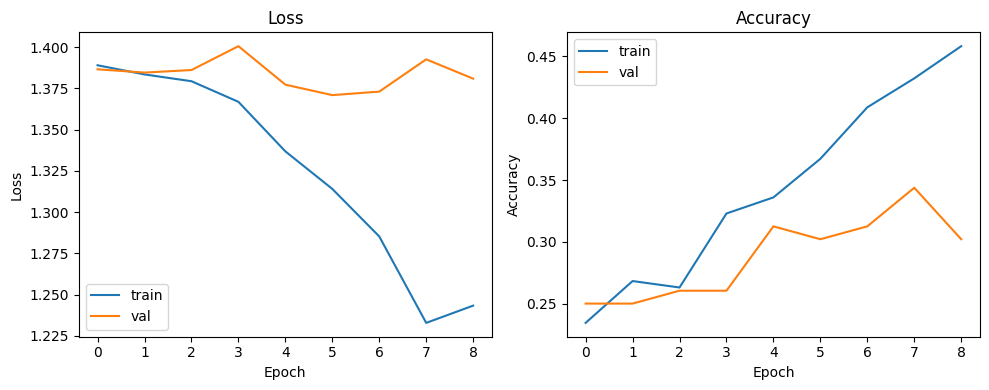

In [51]:
print(">>> Starting load_clean_data\n")
train_flow, val_flow, X_test, y_test = load_clean_data()

print(">>> Defining model")
model = define_cnn_model(image_shape, learning_rate, loss, metrics)

print(">>> Training model")
trained_model = train_cnn_model(model, train_flow, val_flow, X_test, y_test, model_dir, epochs)

